<h1 style="color:magenta;">NSL - Exercises 09 </h1>

### 7/5/2026
### Giulia Federica Bianca Coppi (84486A)

## Ex 1

The Traveling Salesman Problem (TSP) is a classic NP-hard problem in combinatorial optimization. Given a set of $N=34$ cities, the objective is to find the shortest path that visits each city exactly once and returns to the initial starting position. As the number of cities increases, an exhaustive brute-force search becomes computationally intractable. To tackle this, a **Genetic Algorithm (GA)** was implemented, a stochastic optimization technique modeled on the principles of natural selection and evolutionary biology.

In the developed framework:
* **Representation and Constraints:** a path (individual) is represented as a vector of integers corresponding to the ordered sequence of city indices, matched to its cost (its L(1)). To maintain valid paths and satisfy the problem's boundary conditions, the first city is kept fixed and is never altered by any mutation operators. Furthermore, a check function was implemented to continuously verify that each city is visited exactly once.
* **Cost / Loss Function:** the paths are evaluated using the $L^{(1)}$ metric, defined as:
  $$L^{(1)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N) = \sum_{i=1}^{N} |\vec{x}_i-\vec{x}_{i+1}|$$
  where $\vec{x}_{N+1} = \vec{x}_1$ to ensure the closure of the loop
* **Selection Mechanism:** the population is sorted according to fitness: the fitness should be $fitness = 1/{length \, of \, route}$ but in this case I decided to directly use the cost (length) of the path because it implied a better computational efficiency (I didn't have to compute $1/cost$, the sorting result is exactly the same). Parents are selected for reproduction via the operator $j = \text{int}(N_{pop} \times r^p)$, where $r$ is a uniform random number in $[0,1)$ and the exponent $p>1$ (I chose $p=3$) scales the selection pressure
* **Genetic Operators:** to explore the search space, a **Crossover** operator was implemented with a high probability ($75\%$). Additionally, several **Mutation** operators were integrated with a lower probability ($8\%$) to maintain genetic diversity:
  1. pair permutation of two random cities
  2. shift of $n$ contiguous cities
  3. permutation of $n$ contiguous cities between two different blocks
  4. inversion of the order of $m$ contiguous cities

The Genetic Algorithm was applied on two distinct spatial configurations of 34 cities:
1. **Cities randomly placed on a circumference** of unit radius.
2. **Cities randomly placed inside a square** of side length 2 (defined within the boundary $[-1,1] \times [-1,1]$).

The convergence profiles show the $L^{(1)}$ cost of the best path alongside the population average of the best half ($\langle L^{(1)} \rangle$) as a function of the generation number, followed by the Cartesian plot of the optimized route.

#### Cities on a circumference
* **Convergence:** the loss function for the best path drops sharply within the first few generations and quickly hits a stable plateau. The average cost of the best half of the population ($\langle L^{(1)} \rangle$) tightly tracks the best individual, showing that the population rapidly converges uniformly towards the optimum without getting stuck in premature configurations
* **Best route:** the cartesian path plot shows that the algorithm successfully maps a closed loop around the perimeter of the circle without any overlapping tracks or intersecting paths. Since the absolute global minimum for a circular distribution is uniquely defined by following the angular sequence of the coordinates, this result serves as a successful validation test for the optimization algorithm and the genetic operators

#### Cities inside a square
* **Convergence:** compared to the circular arrangement, this configuration demands a higher number of generations to reach an optimal path. The $L^{(1)}$ and $\langle L^{(1)} \rangle$ curves exhibit a "step-like" downward trend. This behavior indicates that the system periodically gets trapped in local minima until a beneficial mutation or crossover event introduces the necessary genetic structural shift to jump to a more efficient arrangement
* **Best route:** the final trajectory outlines a highly optimized path connecting all 34 cities. Visually, the complete absence of intersecting self-crossings serves as a qualitative guarantee of a true minimized solution, as Euclidean geometry guarantees that a self-intersecting route can never be the absolute shortest path for a planar TSP

The Genetic Algorithm has proven to be an exceptionally flexible and robust tool for solving combinatorial optimization problems like the TSP. Operating completely free of prior geometric information regarding the actual coordinate positions, relying entirely on the selection feedback of the loss function, the algorithm successfully "learned" the underlying spatial layout of the environment. It consistently uncovered the global minimum for the circular layout and produced a highly efficient, minimum-length solution for the random square distribution.

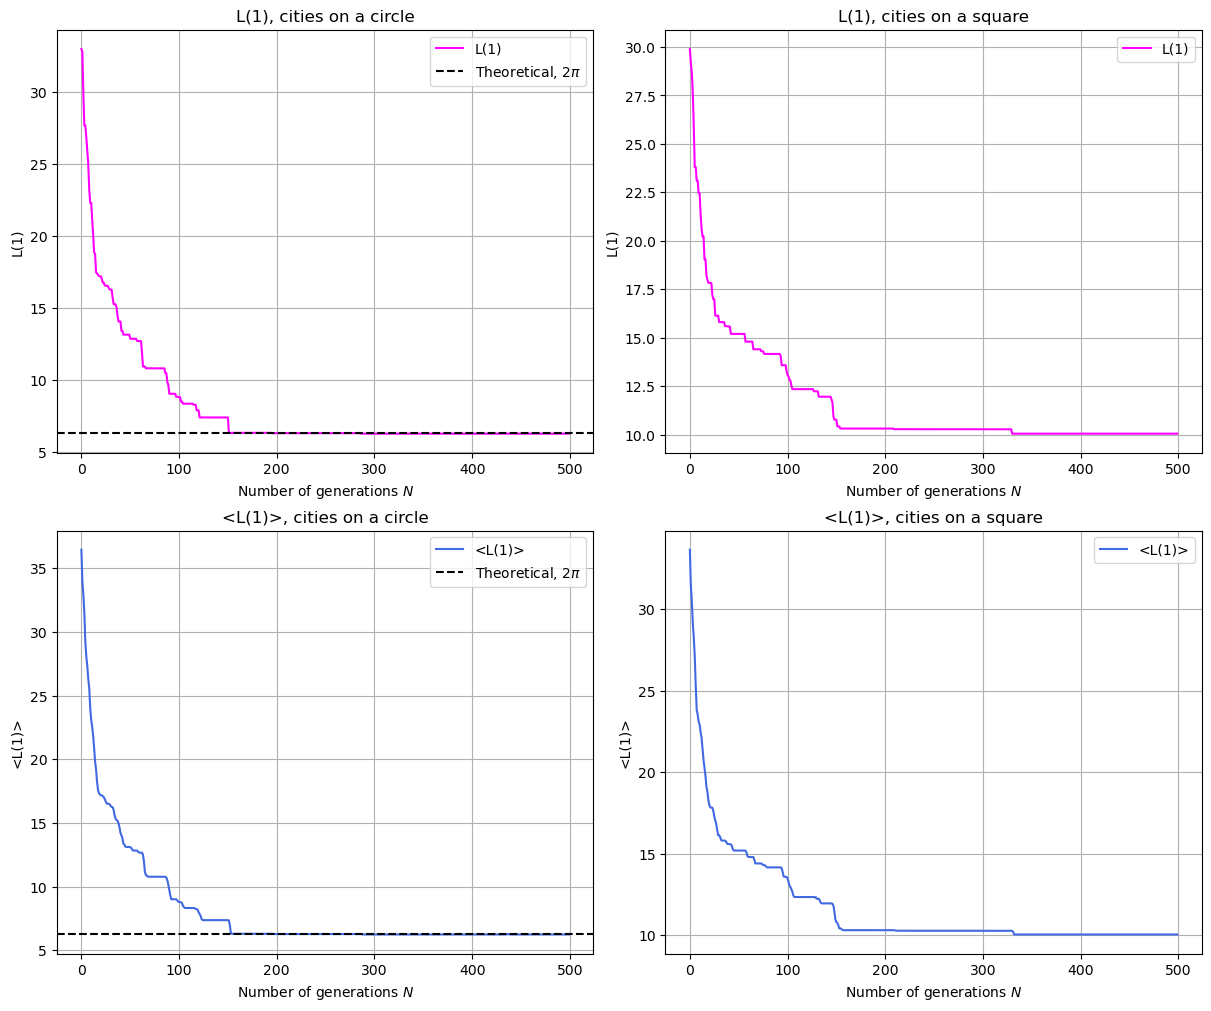

In [7]:
import matplotlib.pyplot as plt
import numpy as np

circle_L = np.loadtxt("./Ex/output_L_1_circle.dat")
circle_L_mean = np.loadtxt("./Ex/output_L_1_mean_circle.dat")

square_L = np.loadtxt("./Ex/output_L_1_square.dat")
square_L_mean = np.loadtxt("./Ex/output_L_1_mean_square.dat")

x_circle = circle_L[:, 0]
y_circle = circle_L[:, -1]
x_circle_mean = circle_L_mean[:, 0]
y_circle_mean = circle_L_mean[:, 1]

x_square = square_L[:, 0]
y_square = square_L[:, -1]
x_square_mean = square_L_mean[:, 0]
y_square_mean = square_L_mean[:, 1]



fig, ax = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)

ax[0, 0].plot(x_circle, y_circle, color='magenta', label='L(1)')
ax[0, 0].set_title("L(1), cities on a circle")
ax[0, 0].set_xlabel("Number of generations $N$")
ax[0, 0].set_ylabel("L(1)")
ax[0, 0].axhline(y=2*np.pi, color='black', linestyle='--', label='Theoretical, $2\pi$')
ax[0, 0].legend()
ax[0, 0].grid(True)

ax[0, 1].plot(x_square, y_square, color='magenta', label='L(1)')
ax[0, 1].set_title("L(1), cities on a square")
ax[0, 1].set_xlabel("Number of generations $N$")
ax[0, 1].set_ylabel("L(1)")
#ax[0, 1].axhline(y=2*np.pi, color='black', linestyle='--', label='Theoretical, $2\pi$')
ax[0, 1].legend()
ax[0, 1].grid(True)

ax[1, 0].plot(x_circle_mean, y_circle_mean, color='royalblue', label='<L(1)>')
ax[1, 0].set_title("<L(1)>, cities on a circle")
ax[1, 0].set_xlabel("Number of generations $N$")
ax[1, 0].set_ylabel("<L(1)>")
ax[1, 0].axhline(y=2*np.pi, color='black', linestyle='--', label='Theoretical, $2\pi$')
ax[1, 0].legend()
ax[1, 0].grid(True)

ax[1, 1].plot(x_square_mean, y_square_mean, color='royalblue', label='<L(1)>')
ax[1, 1].set_title("<L(1)>, cities on a square")
ax[1, 1].set_xlabel("Number of generations $N$")
ax[1, 1].set_ylabel("<L(1)>")
ax[1, 1].legend()
ax[1, 1].grid(True)


plt.show()


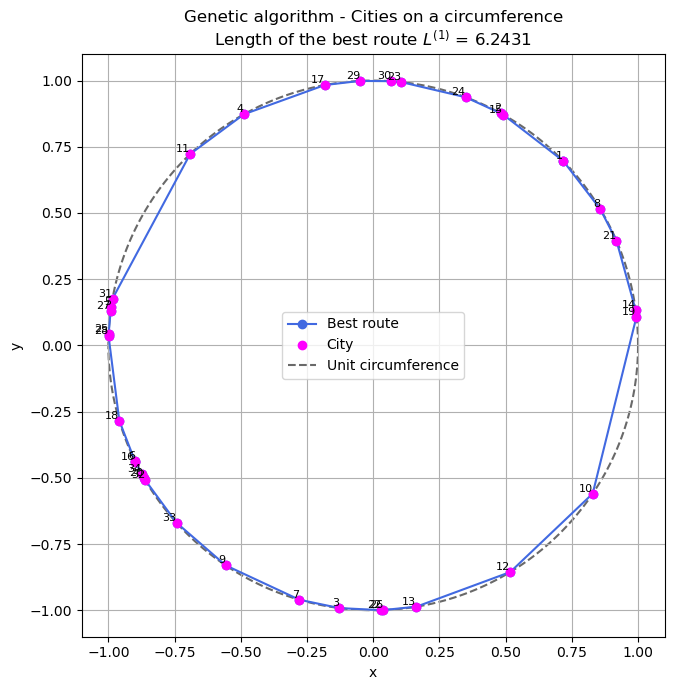

In [10]:
import matplotlib.pyplot as plt
import numpy as np

def load_and_plot_circle(ax, cities_file, route_file, title):
    city_indices, x, y = np.loadtxt(cities_file, unpack=True, usecols=(0, 1, 2))
    city_indices = city_indices.astype(int)

    all_generations = np.loadtxt(route_file)
    
    last_gen_data = all_generations[-1]
    
    best_route = last_gen_data[1:-1].astype(int) - 1
    
    n_cities = len(best_route)
    best_route_coord = np.zeros((2, n_cities + 1))

    for i in range(n_cities):
        city_num = best_route[i]
        index = np.where(city_indices == city_num)[0][0]
        best_route_coord[0, i] = x[index]
        best_route_coord[1, i] = y[index]

    best_route_coord[:, -1] = best_route_coord[:, 0]

    ax.plot(best_route_coord[0], best_route_coord[1], 'o-', label='Best route', color='royalblue', zorder=2)
    ax.plot(x, y, 'o', label='City', color='magenta', zorder=3)

    for i in range(len(city_indices)):
        ax.text(x[i], y[i], str(city_indices[i] + 1), fontsize=8, ha='right', va='bottom')

    theta = np.linspace(0, 2*np.pi, 300)
    ax.plot(np.cos(theta), np.sin(theta), color='dimgray', linestyle='--', label='Unit circumference', zorder=1)

    ax.set_aspect('equal')
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    
    final_cost = last_gen_data[-1]
    ax.set_title(f"{title}\nLength of the best route $L^{{(1)}}$ = {final_cost:.4f}")
    ax.legend()
    ax.grid(True)

fig, ax = plt.subplots(figsize=(7, 7))
load_and_plot_circle(ax, "Ex/output_circle_city.dat", "Ex/output_L_1_circle.dat", "Genetic algorithm - Cities on a circumference")

plt.tight_layout()
plt.show()

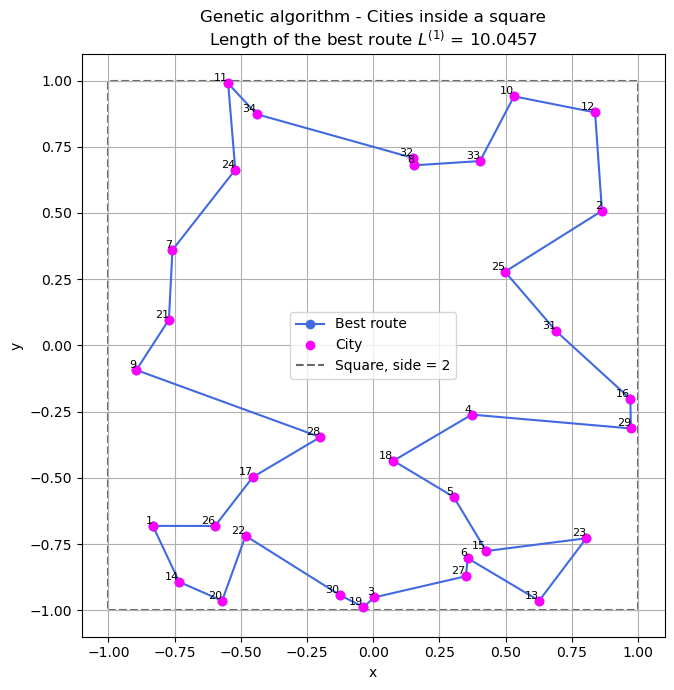

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def load_and_plot_square(ax, cities_file, route_file, title):
    city_indices, x, y = np.loadtxt(cities_file, unpack=True, usecols=(0, 1, 2))
    city_indices = city_indices.astype(int)

    all_generations = np.loadtxt(route_file)
    
    last_gen_data = all_generations[-1]
    
    best_route = last_gen_data[1:-1].astype(int) - 1
    
    n_cities = len(best_route)
    best_route_coord = np.zeros((2, n_cities + 1)) 
    
    for i in range(n_cities):
        city_num = best_route[i]
        index = np.where(city_indices == city_num)[0][0]
        best_route_coord[0, i] = x[index]
        best_route_coord[1, i] = y[index]

    best_route_coord[:, -1] = best_route_coord[:, 0]

    ax.plot(best_route_coord[0], best_route_coord[1], 'o-', label='Best route', color='royalblue', zorder=2)
    ax.plot(x, y, 'o', label='City', color='magenta', zorder=3)

    for i in range(len(city_indices)):
        ax.text(x[i], y[i], str(city_indices[i] + 1), fontsize=8, ha='right', va='bottom')

    square_x = [-1,  1, 1, -1, -1]
    square_y = [-1, -1, 1,  1, -1]
    ax.plot(square_x, square_y, color='dimgray', linestyle='--', label='Square, side = 2', zorder=1)

    ax.set_aspect('equal')
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    
    final_cost = last_gen_data[-1]
    ax.set_title(f"{title}\nLength of the best route $L^{{(1)}}$ = {final_cost:.4f}")
    ax.legend()
    ax.grid(True)
    
fig, ax = plt.subplots(figsize=(7, 7))
load_and_plot_square(ax, "Ex/output_square_city.dat", "Ex/output_L_1_square.dat", "Genetic algorithm - Cities inside a square")

plt.tight_layout()
plt.show()